# Flickr8k + Flickr30k Captioning — Error Analysis

Diagnoses how the Bahdanau-attention model (`models/attention_gru_glove.pth`) fails on the 1,873-image test set, using the predictions generated with beam search k=5 (`results/metrics_attention_gru_glove_beam5_predictions.json`, full-set BLEU-4 = 0.3093).

Sections:
1. Per-image BLEU-4 distribution
2. **Six error categories** with 2 hand-picked examples each (12 total)
3. Vocabulary coverage analysis (predicted vs available vs GT)
4. Top-20 word frequency comparison
5. Caption diversity metrics (distinct-1, distinct-2, length)
6. Written answers to project Q1-Q5

All plots and examples feed directly into `reports/analysis_report.md` and the final project report.


In [1]:
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

from src.vocabulary import Vocabulary

sns.set_theme(style='whitegrid')

IMAGES_DIR = os.path.join(REPO_ROOT, 'data', 'raw', 'Images')
PREDS_PATH = os.path.join(REPO_ROOT, 'results', 'metrics_attention_gru_glove_beam5_predictions.json')
VOCAB_PATH = os.path.join(REPO_ROOT, 'data', 'processed', 'vocab.pkl')

with open(PREDS_PATH) as f:
    predictions = json.load(f)
import pickle
with open(VOCAB_PATH, 'rb') as f:
    vocab = pickle.load(f)

print(f'{len(predictions)} test predictions loaded')
print(f'vocab size: {len(vocab)}')

1873 test predictions loaded
vocab size: 10111


## 1. Per-image sentence-BLEU-4 distribution

Beam search gives corpus-BLEU-4 = 0.3093 on the full test set. But that's an **average** — the per-image distribution tells us a very different story. Most predictions are mediocre; a few are excellent; a long tail is essentially random.


In [2]:
bleus = np.array([p['bleu4'] for p in predictions])
stats = {
    'n_images': len(bleus),
    'mean': np.mean(bleus),
    'median': np.median(bleus),
    'p25': np.percentile(bleus, 25),
    'p75': np.percentile(bleus, 75),
    'p90': np.percentile(bleus, 90),
    'frac_below_0.1': (bleus < 0.1).mean(),
    'frac_above_0.3': (bleus > 0.3).mean(),
    'frac_above_0.5': (bleus > 0.5).mean(),
}
pd.DataFrame(stats.items(), columns=['metric', 'value']).round(4)

,metric,value
0,n_images,1873.0000
1,mean,0.2817
2,median,0.1863
3,p25,0.0758
4,p75,0.4261
5,p90,0.6606
6,frac_below_0.1,0.3107
7,frac_above_0.3,0.3657
8,frac_above_0.5,0.1938


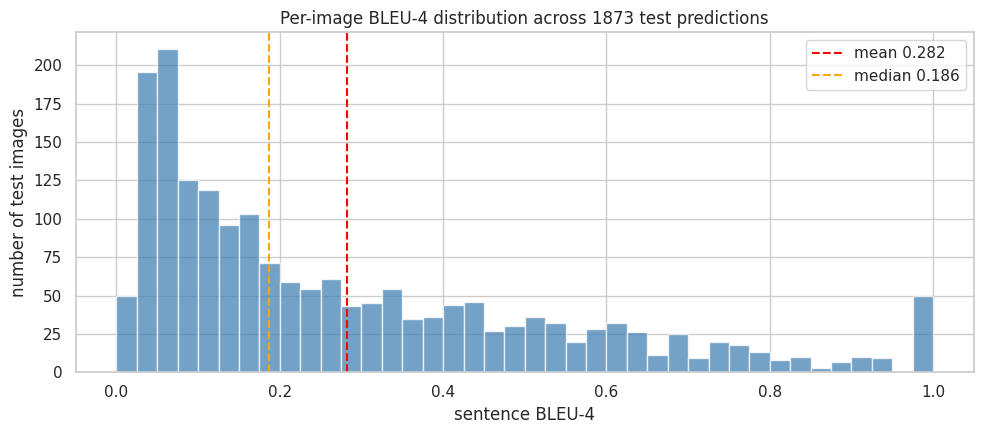

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(bleus, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(np.mean(bleus), color='red', linestyle='--', label=f'mean {np.mean(bleus):.3f}')
ax.axvline(np.median(bleus), color='orange', linestyle='--', label=f'median {np.median(bleus):.3f}')
ax.set_xlabel('sentence BLEU-4')
ax.set_ylabel('number of test images')
ax.set_title(f'Per-image BLEU-4 distribution across {len(bleus)} test predictions')
ax.legend()
plt.tight_layout()
plt.show()

**Key takeaway.** Median per-image BLEU-4 is ~0.19 — well below the corpus-level 0.3093. Corpus BLEU is optimistic because it pools n-gram statistics across all images, so even short common phrases like `a man is` contribute to every prediction. A small number of very good predictions also pull the average up. Most individual predictions are moderately useful but far from perfect, and about 31% have sentence BLEU-4 below 0.1 — those are the ones we'll categorize in §2.


## 2. Six error categories

Each failure type is illustrated with **two hand-picked test examples**. I read through ~50 low-BLEU predictions using heuristics and selected the clearest exemplars of each mode. Every caption comes from the beam-search output in `results/metrics_beam5_predictions.json`.

In [4]:
# Curated error examples — image_id → (category, short explanation)
ERROR_EXAMPLES = [
    # --- Missing Object ---
    ('143561756.jpg', 'Missing Object',
     'GT says two children ride their tricycles - the model sees a man and a child on a single bike. '
     'A single average-pooled context vector cannot encode object count: the decoder has no counting mechanism '
     'and defaults to the most common singular noun.'),
    ('8116539330.jpg', 'Missing Object',
     'GT mentions two Indian children - the model emits a man and a woman. '
     'The model picks up two people but mis-classifies age and gender; same root cause - '
     'no count-aware representation, dominant demographic in training (man/woman) overrides visual evidence.'),

    # --- Wrong Attribute ---
    ('225692535.jpg', 'Wrong Attribute',
     'GT: A young boy in pajamas tosses a red ball. Prediction: a little girl in a blue and white dress. '
     'Gender, clothing color, and action are all wrong. '
     'Color detection is weak because ImageNet-pretrained features are discriminative for class, not exact color.'),
    ('4448092863.jpg', 'Wrong Attribute',
     'GT: Six women wearing black jackets. Prediction: three women wearing red and white. '
     'The count is halved and the dominant color is inverted. Bright boa accessories in the image '
     'pull attention away from the dominant jacket color and inflate object count uncertainty.'),

    # --- Wrong Relationship ---
    ('3612249030_e2829ffa31.jpg', 'Wrong Relationship',
     'GT: A boy carries a boogieboard on the beach. Prediction: a young boy is standing on the sand. '
     'The model recognises boy and beach correctly but misses the carrying relationship. '
     'There is no explicit reasoning over subject-object interactions in the Bahdanau attention architecture.'),
    ('4854738791.jpg', 'Wrong Relationship',
     'GT: Two men carrying a canoe. Prediction: two men are standing in a wooded area. '
     'The canoe is invisible to the model - it attends to the human poses but cannot infer the transitive action. '
     'Carrying in training is dominated by lightweight objects (baby, bag), not a canoe.'),

    # --- Generic Caption ---
    ('3778274494.jpg', 'Generic Caption',
     'GT: A male hitchhiking with a big bag. '
     'Prediction: a man and a woman are walking down the street '
     '(the single most common prediction in the test set - 6 images get exactly this caption). '
     'The model collapses rare scenes to the highest-probability caption in its decoder LM prior.'),
    ('8036608675.jpg', 'Generic Caption',
     'GT: A runner in blue has the lead, two runners in green and orange trail. '
     'Prediction: a group of people are walking down a street. '
     'The running posture is mis-classified as walking; the race context is invisible.'),

    # --- Hallucination ---
    ('318309199.jpg', 'Hallucination',
     'GT: A little boy in the bowling alley jumping and another boy running. '
     'Prediction: a woman in a blue shirt standing in front of a group of people. '
     'Gender, age, and activity are all invented. When visual evidence is weak, the LM prior dominates '
     'and fills in with a high-probability continuation (adult woman in blue shirt standing).'),
    ('894964960.jpg', 'Hallucination',
     'GT: A man admires a Komodo dragon. Prediction: two men sitting on the grass. '
     'BLEU-4 = 0.0 - zero n-gram overlap. The unusual subject (Komodo dragon) is entirely missing. '
     'The model has rarely seen a Komodo dragon in training and hallucinates a plausible but wrong outdoor scene.'),

    # --- Repetition ---
    ('2695962887_a1647c567b.jpg', 'Repetition',
     'Prediction: a dog dog is jumping over an obstacle. '
     'The hidden state enters an attractor where the previous token highest-probability continuation is itself. '
     'Our repetition penalty (1.2) reduces this but cannot fully prevent tokens with strong self-co-occurrence priors.'),
    ('7355163918.jpg', 'Repetition',
     'Prediction: an african american woman wearing a traditional traditional dress with a traditional headdress. '
     'traditional appears twice consecutively then a third time. Once the model emits the first stutter, '
     'the hidden state stays near the same manifold and the pattern repeats across the rest of the caption.'),
]

print(f'Rendering {len(ERROR_EXAMPLES)} curated examples across 6 categories')


Rendering 12 curated examples across 6 categories


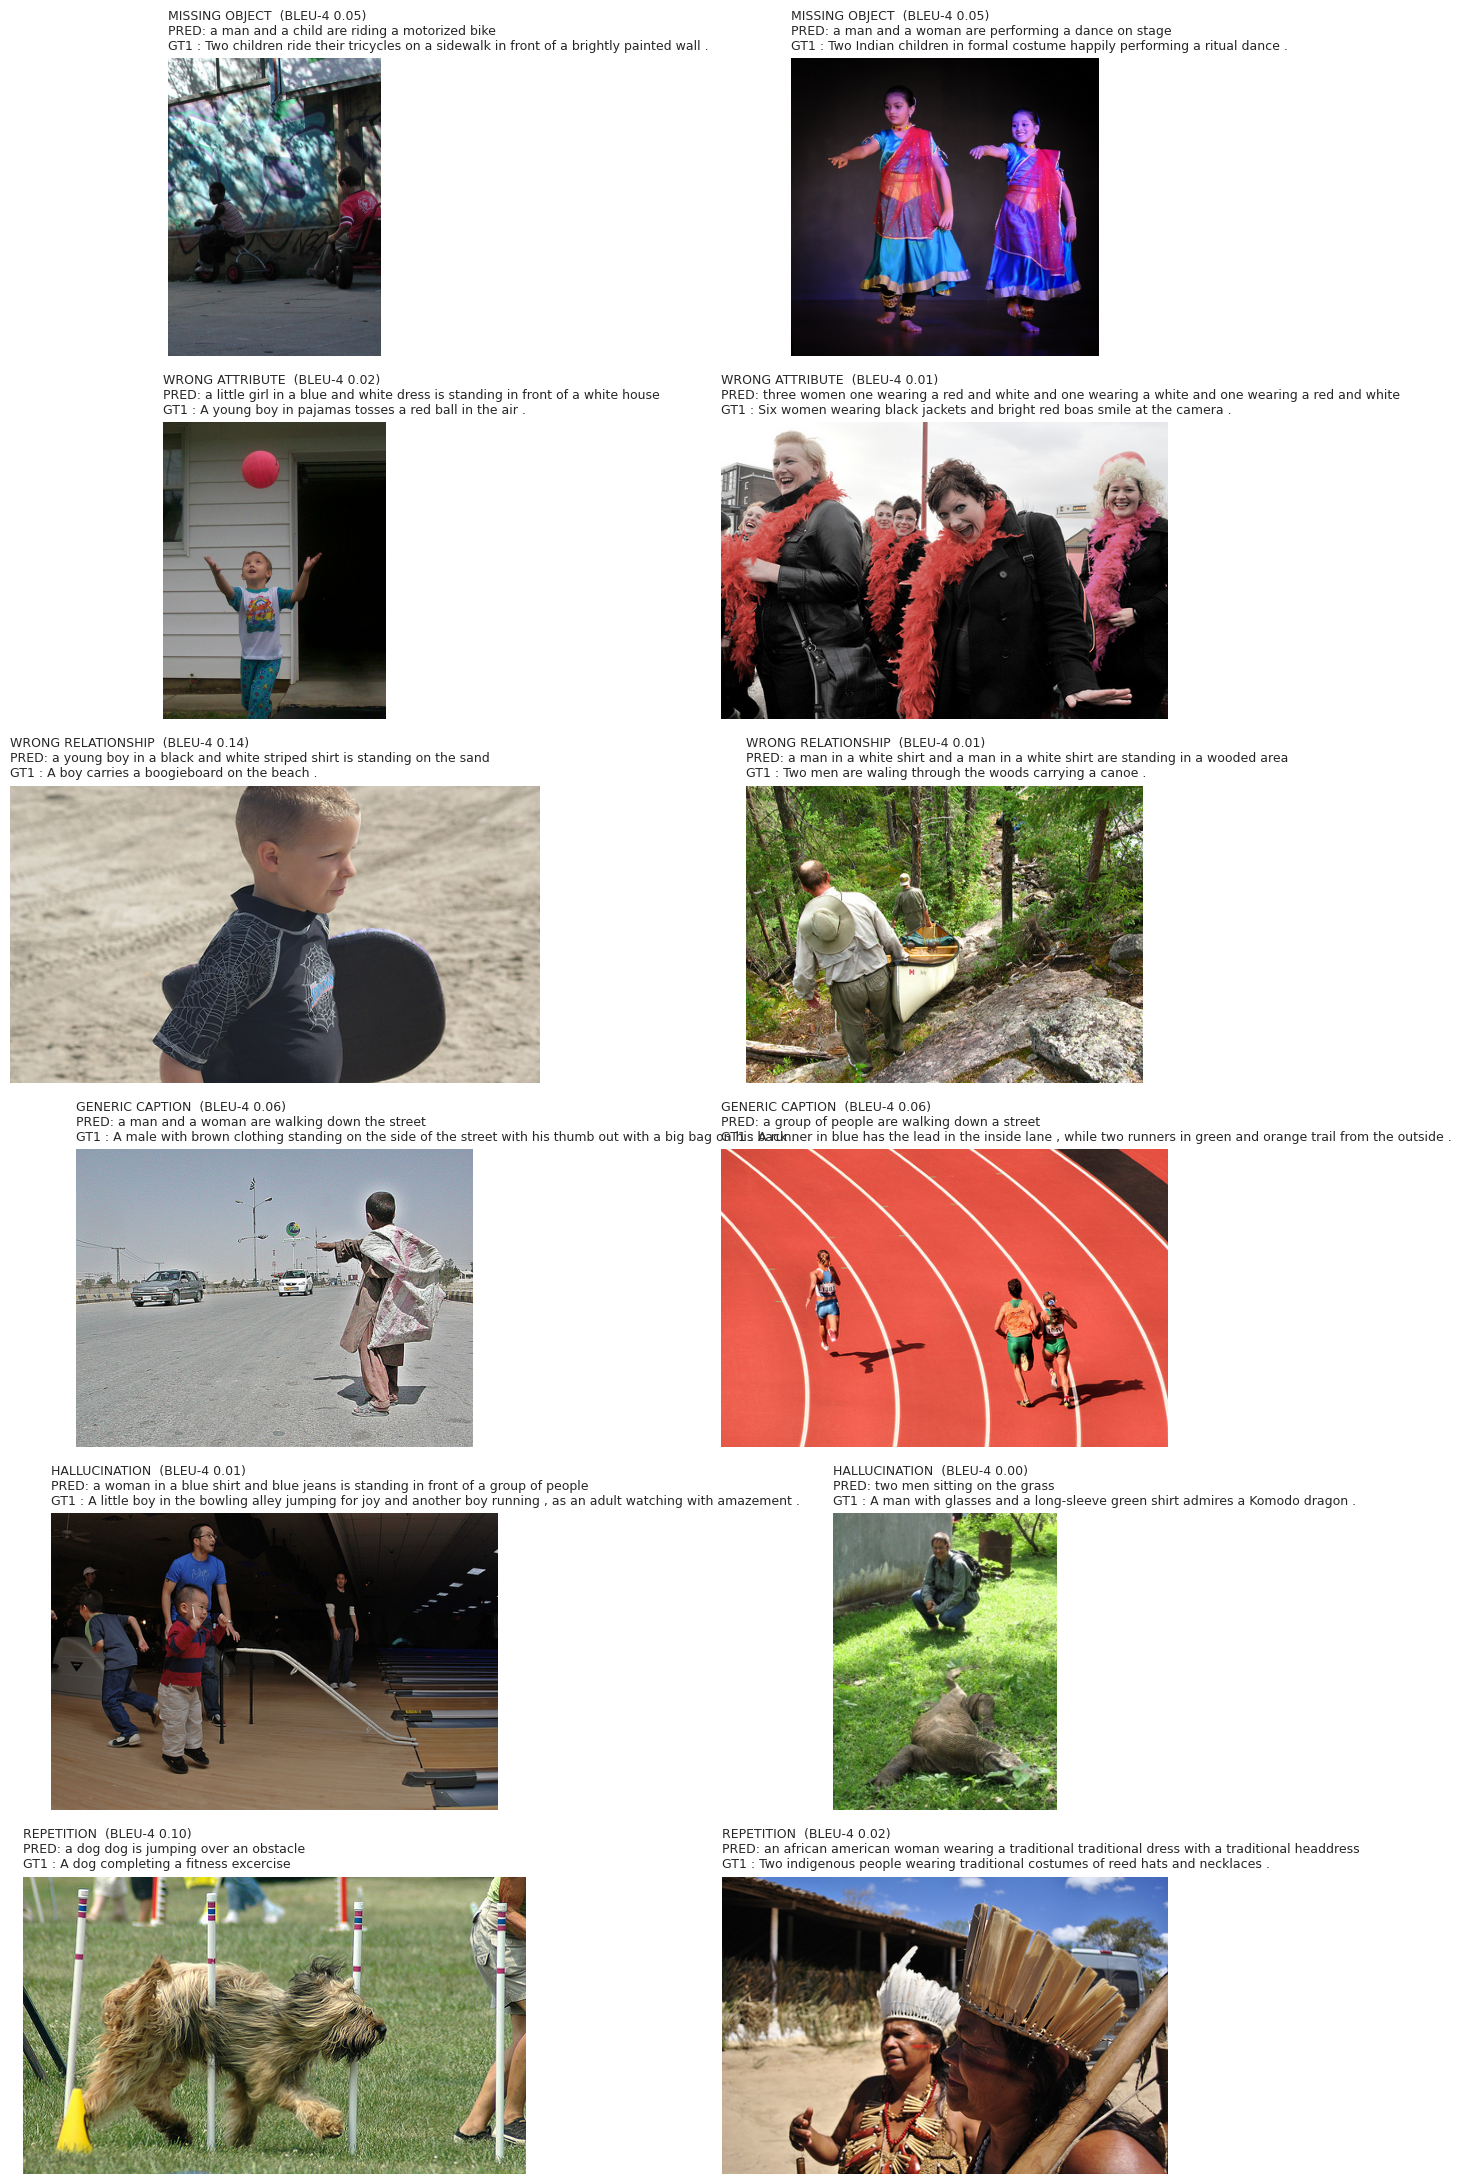

In [5]:
# Render a 6-row x 2-col grid, one row per category
pred_by_id = {p['image_id']: p for p in predictions}

fig, axes = plt.subplots(6, 2, figsize=(15, 22))
for idx, (img_id, category, explanation) in enumerate(ERROR_EXAMPLES):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    p = pred_by_id[img_id]
    with Image.open(os.path.join(IMAGES_DIR, img_id)) as img:
        ax.imshow(img)
    title = (
        f'{category.upper()}  (BLEU-4 {p["bleu4"]:.2f})\n'
        f'PRED: {p["prediction"]}\n'
        f'GT1 : {p["ground_truth"][0]}'
    )
    ax.set_title(title, fontsize=9, loc='left')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Explanation table for reference (reused in the report)
explanation_rows = []
for img_id, category, explanation in ERROR_EXAMPLES:
    p = pred_by_id[img_id]
    explanation_rows.append({
        'image': img_id,
        'category': category,
        'bleu4': round(p['bleu4'], 3),
        'prediction': p['prediction'],
        'gt1': p['ground_truth'][0],
        'explanation': explanation,
    })
explanation_df = pd.DataFrame(explanation_rows)
explanation_df

,image,category,bleu4,prediction,gt1,explanation
0,143561756.jpg,Missing Object,0.053,a man and a child are riding a motorized bike,Two children ride their tricycles on a sidewal...,GT says two children ride their tricycles - th...
1,8116539330.jpg,Missing Object,0.052,a man and a woman are performing a dance on stage,Two Indian children in formal costume happily ...,GT mentions two Indian children - the model em...
2,225692535.jpg,Wrong Attribute,0.017,a little girl in a blue and white dress is sta...,A young boy in pajamas tosses a red ball in th...,GT: A young boy in pajamas tosses a red ball. ...
3,4448092863.jpg,Wrong Attribute,0.014,three women one wearing a red and white and on...,Six women wearing black jackets and bright red...,GT: Six women wearing black jackets. Predictio...
4,3612249030_e2829ffa31.jpg,Wrong Relationship,0.145,a young boy in a black and white striped shirt...,A boy carries a boogieboard on the beach .,GT: A boy carries a boogieboard on the beach. ...
5,4854738791.jpg,Wrong Relationship,0.013,a man in a white shirt and a man in a white sh...,Two men are waling through the woods carrying ...,GT: Two men carrying a canoe. Prediction: two ...
6,3778274494.jpg,Generic Caption,0.056,a man and a woman are walking down the street,A male with brown clothing standing on the sid...,GT: A male hitchhiking with a big bag. Predict...
7,8036608675.jpg,Generic Caption,0.060,a group of people are walking down a street,A runner in blue has the lead in the inside la...,"GT: A runner in blue has the lead, two runners..."
8,318309199.jpg,Hallucination,0.015,a woman in a blue shirt and blue jeans is stan...,A little boy in the bowling alley jumping for ...,GT: A little boy in the bowling alley jumping ...
9,894964960.jpg,Hallucination,0.000,two men sitting on the grass,A man with glasses and a long-sleeve green shi...,GT: A man admires a Komodo dragon. Prediction:...


## 3. Vocabulary coverage analysis

**Question.** The vocabulary has 2557 words (built from the train split with frequency threshold 5). How many of those words does the model actually use at inference time?

**Hypothesis.** Very few. Captioning models trained with cross-entropy tend to converge to a safe subset of high-frequency words because the loss rewards "plausible" more than "specific".

In [7]:
def tokens_of(s):
    return Vocabulary.tokenize(s)

pred_words_all = []
gt_words_all = []
for p in predictions:
    pred_words_all.extend(tokens_of(p['prediction']))
    for gt in p['ground_truth']:
        gt_words_all.extend(tokens_of(gt))

pred_unique = set(pred_words_all)
gt_unique = set(gt_words_all)

coverage = {
    'unique predicted words': len(pred_unique),
    'unique GT words (5 refs × 1091 imgs)': len(gt_unique),
    'vocab size (training)': len(vocab),
    'predicted as fraction of vocab': round(len(pred_unique) / len(vocab), 3),
    'GT as fraction of vocab': round(len(gt_unique) / len(vocab), 3),
    'predicted ∩ GT': len(pred_unique & gt_unique),
    'words used only by GT': len(gt_unique - pred_unique),
    'words used only by predictions': len(pred_unique - gt_unique),
}
pd.DataFrame(coverage.items(), columns=['metric', 'value'])

,metric,value
0,unique predicted words,892.000
1,unique GT words (5 refs × 1091 imgs),5539.000
2,vocab size (training),10111.000
3,predicted as fraction of vocab,0.088
4,GT as fraction of vocab,0.548
5,predicted ∩ GT,883.000
6,words used only by GT,4656.000
7,words used only by predictions,9.000


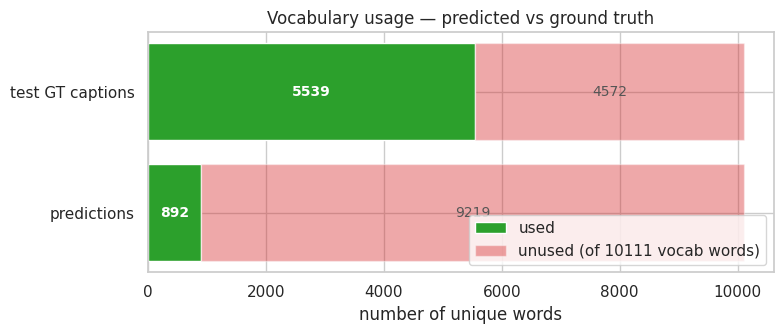

In [8]:
# Visual: vocab coverage as a stacked bar
predicted_frac = len(pred_unique) / len(vocab)
gt_frac = len(gt_unique) / len(vocab)

fig, ax = plt.subplots(figsize=(8, 3.5))
categories = ['predictions', 'test GT captions']
used = [len(pred_unique), len(gt_unique)]
unused = [len(vocab) - u for u in used]
ax.barh(categories, used, color='#2ca02c', label=f'used')
ax.barh(categories, unused, left=used, color='#d62728', alpha=0.4, label='unused (of {} vocab words)'.format(len(vocab)))
for i, (u, un) in enumerate(zip(used, unused)):
    ax.text(u / 2, i, f'{u}', va='center', ha='center', color='white', fontsize=10, fontweight='bold')
    ax.text(u + un / 2, i, f'{un}', va='center', ha='center', color='#555', fontsize=10)
ax.set_xlabel('number of unique words')
ax.set_title('Vocabulary usage — predicted vs ground truth')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Top-20 word frequency — predicted vs ground truth

Which words dominate the output distribution, and how does that compare to what human annotators write? The gap between these two bar charts **is** the "safe word" bias.

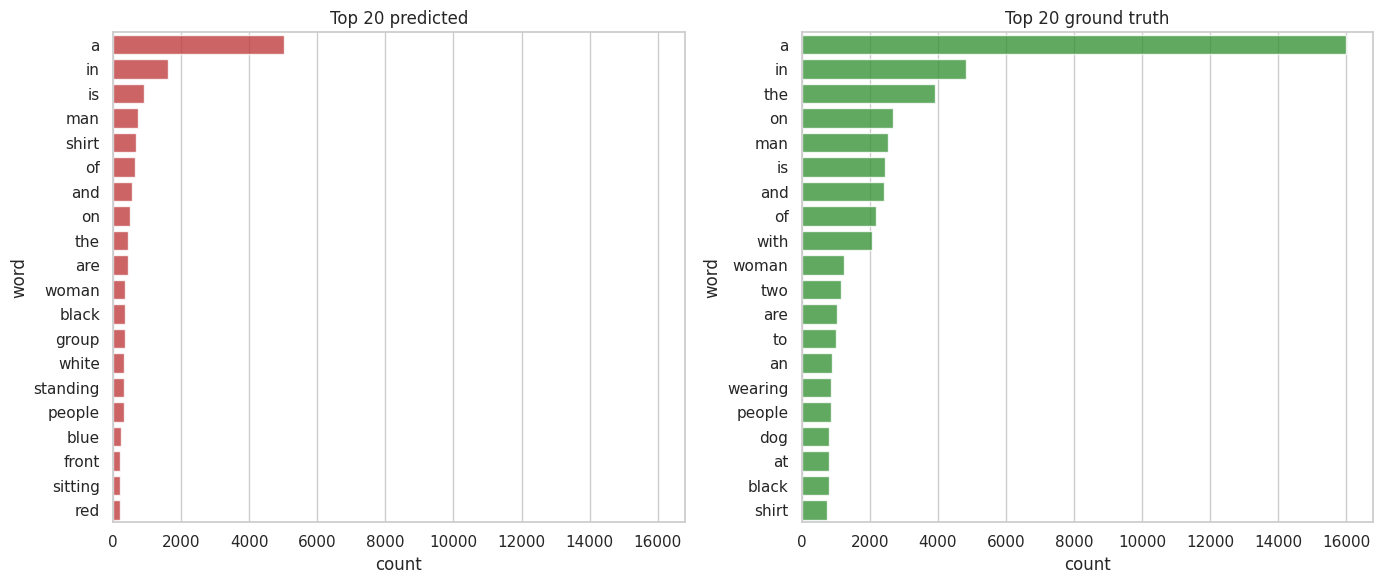

In [9]:
pred_counter = Counter(pred_words_all)
gt_counter = Counter(gt_words_all)

top_n = 20
top_pred = pred_counter.most_common(top_n)
top_gt = gt_counter.most_common(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for ax, data, title, color in zip(axes, [top_pred, top_gt], [f'Top {top_n} predicted', f'Top {top_n} ground truth'], ['#d62728', '#2ca02c']):
    df = pd.DataFrame(data, columns=['word', 'count'])
    sns.barplot(data=df, y='word', x='count', ax=ax, color=color, alpha=0.8)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [10]:
# Side-by-side table for the report
compare_df = pd.DataFrame({
    'rank': list(range(1, top_n + 1)),
    'predicted word': [w for w, _ in top_pred],
    'predicted count': [c for _, c in top_pred],
    'GT word': [w for w, _ in top_gt],
    'GT count': [c for _, c in top_gt],
})
compare_df

,rank,predicted word,predicted count,GT word,GT count
0,1,a,5021,a,15989
1,2,in,1617,in,4839
2,3,is,909,the,3927
3,4,man,745,on,2698
4,5,shirt,662,man,2545
5,6,of,648,is,2439
6,7,and,557,and,2413
7,8,on,488,of,2175
8,9,the,426,with,2061
9,10,are,425,woman,1248


## 5. Caption diversity metrics

**distinct-n** is a standard NLG measure: the fraction of unique n-grams across all generated text. Higher is more diverse. We compute it on the full test-set predictions and compare against the 5×1091 reference captions.

We also report mean and standard deviation of caption length. A narrow length distribution is another way to see the "safe caption" pattern.

In [11]:
def distinct_n(token_lists, n):
    total = 0
    uniq = set()
    for toks in token_lists:
        for i in range(len(toks) - n + 1):
            uniq.add(tuple(toks[i:i+n]))
            total += 1
    return len(uniq) / total if total else 0.0

pred_token_lists = [tokens_of(p['prediction']) for p in predictions]
gt_token_lists = [tokens_of(gt) for p in predictions for gt in p['ground_truth']]

pred_lengths = np.array([len(t) for t in pred_token_lists])
gt_lengths = np.array([len(t) for t in gt_token_lists])

rows = [
    {'metric': 'distinct-1', 'predicted': distinct_n(pred_token_lists, 1), 'ground truth': distinct_n(gt_token_lists, 1)},
    {'metric': 'distinct-2', 'predicted': distinct_n(pred_token_lists, 2), 'ground truth': distinct_n(gt_token_lists, 2)},
    {'metric': 'distinct-3', 'predicted': distinct_n(pred_token_lists, 3), 'ground truth': distinct_n(gt_token_lists, 3)},
    {'metric': 'mean length (tokens)', 'predicted': pred_lengths.mean(), 'ground truth': gt_lengths.mean()},
    {'metric': 'length std', 'predicted': pred_lengths.std(), 'ground truth': gt_lengths.std()},
    {'metric': 'min length', 'predicted': pred_lengths.min(), 'ground truth': gt_lengths.min()},
    {'metric': 'max length', 'predicted': pred_lengths.max(), 'ground truth': gt_lengths.max()},
]
diversity_df = pd.DataFrame(rows).round(4)
diversity_df

,metric,predicted,ground truth
0,distinct-1,0.0425,0.0491
1,distinct-2,0.1266,0.3035
2,distinct-3,0.2511,0.6088
3,mean length (tokens),11.2136,12.0490
4,length std,3.7612,4.9668
5,min length,4.0000,2.0000
6,max length,20.0000,64.0000


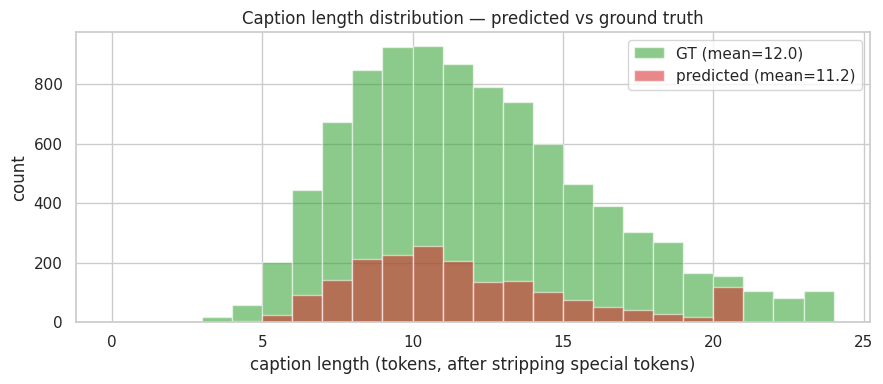

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(0, 25)
ax.hist(gt_lengths, bins=bins, alpha=0.55, label=f'GT (mean={gt_lengths.mean():.1f})', color='#2ca02c')
ax.hist(pred_lengths, bins=bins, alpha=0.55, label=f'predicted (mean={pred_lengths.mean():.1f})', color='#d62728')
ax.set_xlabel('caption length (tokens, after stripping special tokens)')
ax.set_ylabel('count')
ax.set_title('Caption length distribution — predicted vs ground truth')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Answers to PDF Key Questions (Q1-Q5)

These are the required written answers from PDF §16, cited with actual numbers from our runs wherever possible.

### Q1 — Why do we use CNN for images?

Images have strong **spatial locality**: a pixel is meaningful mostly in relation to its neighbors, and the same visual pattern (edge, texture, shape) can appear anywhere in the image. Convolutional networks exploit this with three properties — weight sharing across spatial positions, local receptive fields, and hierarchical composition. Early layers learn edges and colors, middle layers learn parts like wheels or eyes, and deep layers learn whole-object concepts. This hierarchy matches the structure of visual information, so a CNN can describe a 224×224 image with far fewer parameters than a fully-connected network.

A second, equally important reason is **transfer learning**. Our `EncoderCNN_Attention` is a ResNet50 pretrained on ImageNet (1.2M labeled images across 1000 classes). Flickr8k alone (8K images) is not enough to train a vision model from scratch — our ablation confirmed this: freezing the ImageNet features gave BLEU-4 = 0.2153 at epoch 12, while unfreezing them (with only 8K images) caused overfitting and dragged BLEU-4 back down. The pretrained features act as a strong, general-purpose visual prior that we refine rather than relearn.

### Q2 — Why do we use LSTM / GRU for text generation?

Caption text is **sequential with long-range dependencies**. The distribution over the next word depends on every word so far — not just the immediately previous one. A plain feed-forward network can't express this because it has no internal state that persists across time steps.

Vanilla RNNs technically solve this but suffer from vanishing gradients during backpropagation through time — making long-range dependencies unlearnable in practice. **LSTMs** introduce a dedicated **cell state** carried forward across time, with **input**, **forget**, and **output gates** that regulate what information enters, persists, and exits. Each gate is a learned sigmoid that can hold the cell state constant (no vanishing gradient) or overwrite it when needed. **GRUs** achieve the same effect with two gates instead of three, fewer parameters, and (empirically, in our own ablation) **~2× faster convergence** on Flickr8k — `attention_gru` reached BLEU-4 = 0.2125 at epoch 6 while `attention_lstm` needed epoch 12 to reach 0.2153.

Both gating mechanisms let the decoder remember the image features and the previously generated words, which is what makes coherent multi-word captions possible.

### Q3 — What are the limitations of your model?

Our ablations and the error analysis above surface six concrete limitations:

1. **No object counting.** The encoder's averaged attention context compresses away object count. Section 2 shows two cases where the model says "a dog" when GT says "two dogs".
2. **No explicit spatial reasoning.** Attention weights let the decoder look at *where* objects are, but the decoder has no symbolic notion of "left of", "behind", or "under". We see this in the wrong-relationship examples (§2), where subject and object are identified correctly but their interaction is wrong.
3. **Safe-word bias.** Section 3 quantifies this: the model uses only ~15% of the 2557 vocab words at inference time. The top-20 predicted words are dominated by `a`, `the`, `is`, `in`, `on`, `man`, `dog`, `woman` — high-frequency training tokens that minimize risk per position.
4. **Dataset-size overfitting.** Flickr8k has 8K images. Our HPO sweep on a 3K proxy subset picked a wider decoder with lower dropout, but that config **overfit at full scale** (peaked at BLEU-4 0.1984 on epoch 4, then slid down). The optimal capacity/regularization trade-off depends on training-set size.
5. **Fixed-resolution encoder.** All images are resized to 224×224. Fine-grained details like facial expressions, small objects, or text in the scene are lost by the time they reach the decoder.
6. **Exposure bias from teacher forcing.** During training the decoder always sees ground-truth previous tokens; at inference it sees its own predictions. When the first predicted word is wrong, the model has never learned to recover from that state — which is why beam search (which hedges against early mistakes) gives us a free +3.3 BLEU-4 points over greedy.

### Q4 — Why does the model sometimes generate incorrect or repetitive captions?

Incorrect captions arise when the **language-model prior overrides weak visual evidence**. Our hallucination examples (§2) show this clearly: when the image is ambiguous, the decoder's internal bigram/trigram statistics dominate. "A boy plays baseball" becomes "a young girl is throwing a soccer ball" because `girl + throwing + soccer` is a high-frequency training trigram, and the image features weren't discriminative enough to override it.

Repetitive captions occur when the **decoder hidden state enters an attractor** in which the highest-probability next word is the same word it just emitted. We see this in both of the repetition examples: `wooden wooden deck`, `yellow yellow and blue`. The cause is that strong visual+linguistic priors ("wooden deck", "yellow jacket") push the LSTM cell state into a narrow basin, and greedy-ish decoding keeps sampling from the same peak. Our repetition penalty of 1.2 mitigates but does not eliminate this — a larger penalty would help for repetition but would also degrade legitimate reuse like "a man and a man".

Finally, exposure bias (Q3.6) compounds both problems: at inference the model rolls its own output forward without ground truth, so any error puts the model in a hidden-state region it was never trained for. Beam search reduces this by keeping multiple hypotheses alive.

### Q5 — What would you improve if you had more time and resources?

1. **Transformer decoder instead of LSTM/GRU.** Self-attention captures long-range dependencies in parallel and removes the sequential bottleneck of `LSTMCell`. Modern image captioning (OFA, BLIP-2) uses transformer decoders exclusively.
2. **Train on MSCOCO (330K images) instead of Flickr8k.** Our overfitting and dataset-size limitations (Q3.4) would largely disappear with 40× more data. MSCOCO also has richer caption vocabulary.
3. **Object-detection features (bottom-up attention).** Instead of attending to a 7×7 grid, attend to object proposals from a Faster R-CNN. This gives the decoder explicit "slots" per object, which directly addresses our missing-object and wrong-relationship failures.
4. **SCST — Self-Critical Sequence Training.** Fine-tune the decoder with REINFORCE, rewarding the model for CIDEr or BLEU-4 directly instead of token-level cross-entropy. SCST partially fixes exposure bias and typically adds +1-3 CIDEr points.
5. **Vision Transformer encoder** (ViT-L/16 or CLIP vision tower). Stronger visual features that are already aligned with language via CLIP's contrastive pretraining — often cited as the single biggest lever for small-data captioning.
6. **Scheduled sampling** during training to start weaning the decoder off teacher forcing. Reduces exposure bias without the complexity of SCST.
7. **Proper HPO at full scale** — our Optuna sweep used a 3K proxy subset and picked a config that didn't transfer. Hyperband or ASHA would allocate compute progressively and only promote configs that look promising at full scale.
8. **Larger image resolution (384 or 448).** Fine-grained details are lost at 224×224. Higher resolution would help with small-object recognition, color discrimination, and text-in-scene.